In [ ]:
library(tidyverse)
library(lubridate)
library(ggridges)
library(ComplexUpset)


source("../theme_ggplot_cfrna.R")
source("../functions.R")
gene_key = read.delim("../gencode.biotype.name.key.tsv")

In [ ]:
mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% 
    mutate(rel_trans = ymd(date) - ymd(transplant_date)) %>%
    filter(ORIGIN == "DFCI")

mdf %>% 
    filter(sample_group %in% c("COMP","REF")) %>% 
    nrow()

mdf %>% 
    filter(sample_group %in% c("COMP","REF")) %>% 
    pull(Record_ID) %>% unique() %>% 
    length()

In [ ]:
mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% 
    filter(ORIGIN == "DFCI") %>%    
    mutate(aGVHD = grepl("agvhd",all_comps),
            cGVHD = grepl("cgvhd",all_comps),
            BKVR = grepl("bkvr",all_comps),
            # BKVD = grepl("bkvd",all_comps),
            RELAPSE = grepl("relapse",all_comps),
            GRAFTFAIL = grepl("graftfail",all_comps),
            noCOMP = sample_group=="REF")

comps = c("BKVR","aGVHD","cGVHD","RELAPSE","GRAFTFAIL","noCOMP")

# output_list <- lapply(comps, function(x) mdf %>% filter(.data[[x]]) %>% pull(Record_ID) %>% unique() )
# names(output_list) <- comps

size = get_size_mode('exclusive_intersection')


mdf_upset <- mdf %>% 
    ## prepare data
    select(all_of(c("Record_ID",comps))) %>% 
    filter(Record_ID != "HD") %>% 
    unique() %>% 
    remove_rownames() %>% 
    column_to_rownames(.,"Record_ID") %>%
    select(comps)

colnames(mdf_upset) <- lapply(colnames(mdf_upset), function(x) paste0(x," (n=",mdf_upset %>% filter(.data[[x]]) %>% nrow(),")"))


mdf_upset %>% nrow()

    ## run upset function
upset_plt <-  mdf_upset %>% 
    upset(., 
        colnames(mdf_upset), 
        height_ratio = 1,
        set_sizes=FALSE,
        stripe = "white",
        base_annotations = list(
            'Intersection size'=(
                intersection_size(text=list(
                    # vjust=0.1,
                    size = 2),
                    bar_number_threshold = 100)
                + theme_cfrna_print()
                + theme(text = element_text(size = 6),  
                        plot.margin = unit(c(0,0,2,0), "pt"),
                        plot.title = element_text(size = 8, hjust = 0.5, vjust = -2),
                        axis.title.y = element_blank(),
                        axis.text.x = element_blank(),
                        axis.title.x = element_blank())
                + labs(title = "Complication Overlap", y = "Patients in\nIntersection")
                + ylim(0,16)
            )
        ),
        matrix = intersection_matrix(
                geom=geom_point(
                        size = 0.5
                )
                
        )
        
        + theme_cfrna_print()
        + theme(axis.text.y = element_text(size = 6, color = "black"),
                axis.text.x = element_blank())

    )+
    ## customize with ggplot    
    theme(
        plot.margin = unit(c(0,0,0,0), "pt"),
        axis.title.x = element_blank(),
        # axis.title.y = element_text(size = 6, hjust = 0.25),
        axis.text.y = element_text(size = 6, color = "black"),
        text = element_text(size = 6, color = "black"))

WIDTH = 3.5
HEIGHT = 1.8

pdf(file=paste0("./figures/COMPS_upset.pdf"),
        width=WIDTH,height=HEIGHT, paper="special", bg="white",
         colormodel = "srgb", pointsize=6, useDingbats = FALSE)

upset_plt

dev.off()

# mdf_upset %>% head()


Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(comps)

  # Now:
  data %>% select(all_of(comps))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


[1] 114

Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.text.align` theme element is not defined in the element hierarchy.”
Warning message in plot_theme(plot):
“The `legend.title.align` theme element is not defined in the element hierarchy.”


png 
  2

Warning message in stat_compare_means(aes(group = sample_group, method = "wilcox.test", :
“Ignoring unknown aesthetics: method”


Warning message:
“Unknown or uninitialised column: `p`.”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Unknown or uninitialised column: `p`.”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”


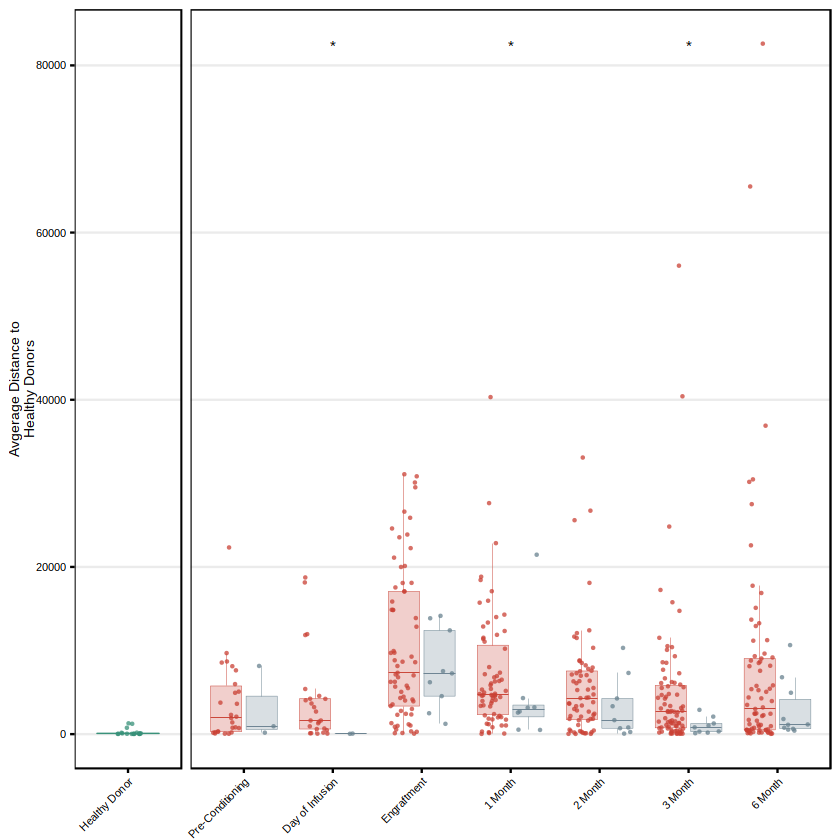

In [ ]:
dist_plt = mdf %>%
  ggplot(aes(x = timepoint_sym, y = avgDist_trajectory, fill = sample_group, color = sample_group)) +

  geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), width = 0.7, alpha = 0.25, size = 0.1) +

  geom_point(size = 1, alpha = 0.75, stroke=NA,
            position =  position_jitterdodge(jitter.height=0, 
                                              jitter.width=.3, 
                                              dodge.width = 0.8, 
                                              seed=42)
              )+
  theme_cfrna_print() +
  theme(
      axis.title.x = element_blank(),
      axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
      legend.position = "none",
      panel.grid.minor.y = element_blank(),       # Remove minor gridlines
      panel.grid.major.x = element_blank(),        # Remove major x gridlines
      strip.text = element_blank(),
      strip.background = element_blank()
    )+
  scale_fill_manual(values = COLORs)+
  scale_color_manual(values = COLORs)+
  theme(plot.title = element_text(size = 8, hjust = 0.5)) +
  facet_grid(~HD, scales = "free_x", space = "free") +
  labs(y = "Avgerage Distance to\nHealthy Donors")

dist_plt + stat_compare_means(
        aes(group = sample_group,method = "wilcox.test", label = after_stat(p.signif)),
        symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf), symbols = c("****", "***", "**", "*", "ns")),
        size = 3,
        vjust = .75,
        hide.ns = TRUE,
        )



WIDTH = 3.5
HEIGHT = 2.25
ggsave("./figures/DIST_all.pdf",width=WIDTH, height = HEIGHT, units = "in")

Warning message:
“Removed 297 rows containing missing values or values outside the scale range
(`geom_point()`).”


png 
  2

Warning message:
“Removed 297 rows containing missing values or values outside the scale range
(`geom_point()`).”


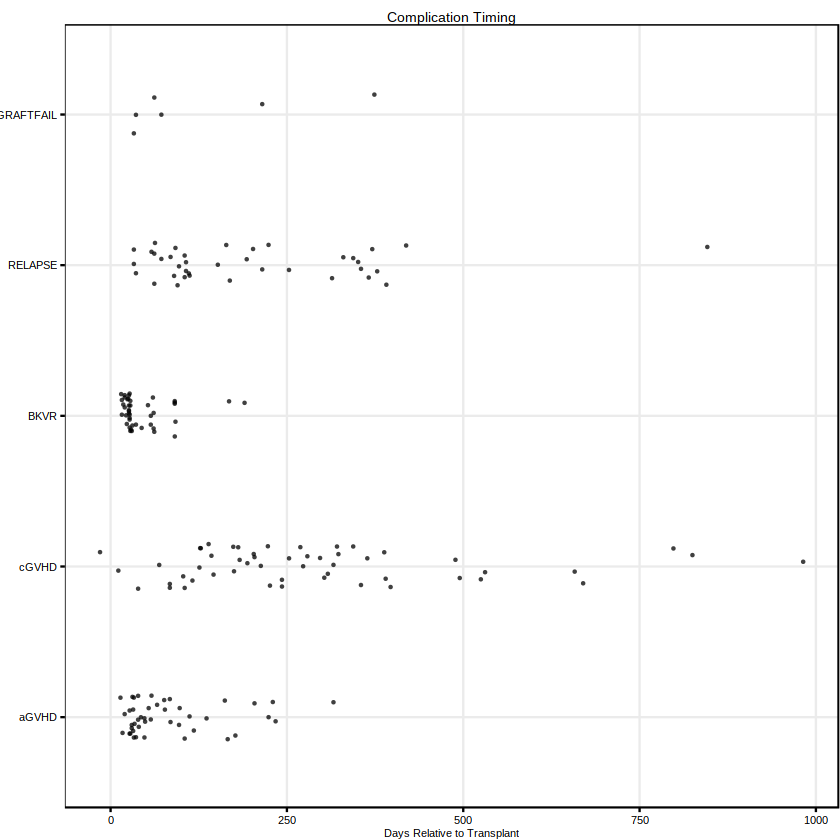

In [ ]:
comps = read.csv("/workdir/cjl332/HCT_DFCI/cfRNA_data/cleaned_clinical_data/complication-dates.csv") %>% 
    filter(Record_ID %in% mdf$Record_ID) %>% 
    mutate(aGVHD_date_dif = as.numeric(difftime(aGVHD_date, date.D0, units = "days")),
            cGVHD_date_dif = as.numeric(difftime(cGVHD_date, date.D0, units = "days")),
            BKVR_date_dif = as.numeric(difftime(BKVR_date, date.D0, units = "days")),
            # BKVD_date_dif = as.numeric(difftime(BKVD_date, date.D0, units = "days")),
            RELAPSE_date_dif = as.numeric(difftime(RELAPSE_GRAFTFAIL_date, date.D0, units = "days")),
            GRAFTFAIL_date_dif = as.numeric(difftime(RELAPSE_GRAFTFAIL_date, date.D0, units = "days"))
            ) %>% 
    mutate(RELAPSE_date_dif = ifelse(RELAPSE == "yes", RELAPSE_date_dif, NA)) %>% 
    mutate(GRAFTFAIL_date_dif = ifelse(GRAFTFAIL == "yes", GRAFTFAIL_date_dif, NA)) %>% 
    select(Record_ID, aGVHD_date_dif, cGVHD_date_dif, BKVR_date_dif, RELAPSE_date_dif, GRAFTFAIL_date_dif) %>%    # BKVD_date_dif
    reshape2::melt(.,"Record_ID") %>% 
    rename(comp = variable, day_rel_transplant = value) %>%
    mutate(comp = gsub("_date_dif","",comp)) %>%
    mutate(comp = factor(comp, levels = c("aGVHD","cGVHD","BKVR","RELAPSE","GRAFTFAIL")))       #,"BKVD"

set.seed(42)
comp_plt <- comps %>% 
    ggplot(aes(x=day_rel_transplant, y = comp))+
    # geom_boxplot(outlier.shape=NA)+
    geom_jitter(width = 0, alpha = 0.75, height = 0.15, stroke=NA, size =1)+
    theme_cfrna_print()+
    labs(x= "Days Relative to Transplant", title = "Complication Timing")+
    theme(
        plot.margin = unit(c(1,1,1,1), "pt"),
        plot.title = element_text(size = 8, hjust = 0.5, vjust = -2),
        axis.title.x = element_text(size = 6),
        axis.title.y = element_blank(),
        title = element_blank(),
        legend.position = "none"
    )

WIDTH = 3.16
HEIGHT= 1.3

pdf(file=paste0("./figures/COMPS_time.pdf"),
        width=WIDTH,height=HEIGHT, paper="special", bg="white",
         colormodel = "srgb", pointsize=6, useDingbats = FALSE)

    print(comp_plt)   

dev.off()

print(comp_plt)